<a href="https://colab.research.google.com/github/Aayushapanda/Autism-Percept-Modelling-with-Hopfield-Network-for-Necker-s-cube/blob/main/Attempt_BERG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(np.float64(-0.5), np.float64(774.5), np.float64(774.5), np.float64(-0.5))

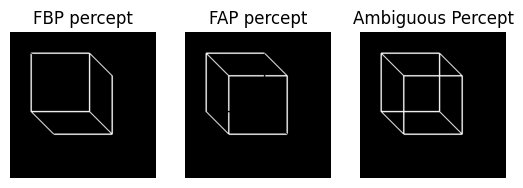

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np

def draw_line(img, x0, y0, x1, y1, thickness=1, intensity=1.0):
    """Bresenham-style line drawing updated to support variable intensity."""
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    x, y = x0, y0

    sx = 1 if x1 > x0 else -1
    sy = 1 if y1 > y0 else -1

    if dx > dy:
        err = dx / 2.0
        while x != x1:
            for t in range(-thickness, thickness+1):
                if 0 <= y+t < img.shape[0] and 0 <= x < img.shape[1]:
                    img[y+t, x] = intensity
            err -= dy
            if err < 0:
                y += sy
                err += dx
            x += sx
    else:
        err = dy / 2.0
        while y != y1:
            for t in range(-thickness, thickness+1):
                if 0 <= y < img.shape[0] and 0 <= x+t < img.shape[1]:
                    img[y, x+t] = intensity
            err -= dx
            if err < 0:
                x += sx
                err += dy
            y += sy

    # last point
    if 0 <= y < img.shape[0] and 0 <= x < img.shape[1]:
        img[y, x] = intensity
def make_fbp_cube(N=128, size=50, offset=20, thickness=1, occlusion_val=0.2):
    """
    Generates a Necker cube representing the FBP (Front-Below Percept).
    The square shifted down/right is perceived as the front face.
    """
    img = np.zeros((N, N))
    cx, cy = N // 2, N // 2

    # Coordinates: 0=Top-Left, 1=Top-Right, 2=Bottom-Right, 3=Bottom-Left
    f = [
        (cx - size//2, cy - size//2),
        (cx + size//2, cy - size//2),
        (cx + size//2, cy + size//2),
        (cx - size//2, cy + size//2),
    ]
    b = [(x - offset, y - offset) for (x, y) in f]

    # In FBP, 'f' is in front. The occluded lines are on 'b' (Right and Bottom edges)
    # and the Bottom-Right connecting line.

    # Draw front square (all solid)
    for i in range(4):
        draw_line(img, *f[i], *f[(i+1)%4], thickness, intensity=1.0)

    # Draw back square (Index 1=Right, Index 2=Bottom are occluded)
    for i in range(4):
        intensity = occlusion_val if i in [1, 2] else 1.0
        draw_line(img, *b[i], *b[(i+1)%4], thickness, intensity=intensity)

    # Connect corners (Index 2=Bottom-Right connection is occluded)
    for i in range(4):
        intensity = occlusion_val if i == 2 else 1.0
        draw_line(img, *f[i], *b[i], thickness, intensity=intensity)

    return img


def make_fap_cube(N=128, size=50, offset=20, thickness=1, occlusion_val=0.2):
    """
    Generates a Necker cube representing the FAP (Front-Above Percept).
    The square shifted up/left is perceived as the front face.
    """
    img = np.zeros((N, N))
    cx, cy = N // 2, N // 2

    # Coordinates: 0=Top-Left, 1=Top-Right, 2=Bottom-Right, 3=Bottom-Left
    f = [
        (cx - size//2, cy - size//2),
        (cx + size//2, cy - size//2),
        (cx + size//2, cy + size//2),
        (cx - size//2, cy + size//2),
    ]
    b = [(x - offset, y - offset) for (x, y) in f]

    # In FAP, 'b' is in front. The occluded lines are on 'f' (Top and Left edges)
    # and the Top-Left connecting line.

    # Draw front square (Index 0=Top, Index 3=Left are occluded)
    for i in range(4):
        intensity = occlusion_val if i in [0, 3] else 1.0
        draw_line(img, *f[i], *f[(i+1)%4], thickness, intensity=intensity)

    # Draw back square (all solid)
    for i in range(4):
        draw_line(img, *b[i], *b[(i+1)%4], thickness, intensity=1.0)

    # Connect corners (Index 0=Top-Left connection is occluded)
    for i in range(4):
        intensity = occlusion_val if i == 0 else 1.0
        draw_line(img, *f[i], *b[i], thickness, intensity=intensity)

    return img

def make_necker_cube(N=128, size=50, offset=20, thickness=1):
    """
    Generates a Necker cube line drawing.

    Parameters:
    - N: image size
    - size: size of front square
    - offset: shift between front and back square
    - thickness: line thickness
    """

    img = np.zeros((N, N))

    cx, cy = N // 2, N // 2

    # Front square
    f = [
        (cx - size//2, cy - size//2),
        (cx + size//2, cy - size//2),
        (cx + size//2, cy + size//2),
        (cx - size//2, cy + size//2),
    ]

    # Back square (shifted up-left)
    b = [(x - offset, y - offset) for (x, y) in f]

    # Draw front square
    for i in range(4):
        draw_line(img, *f[i], *f[(i+1)%4], thickness)

    # Draw back square
    for i in range(4):
        draw_line(img, *b[i], *b[(i+1)%4], thickness)

    # Connect corners
    for i in range(4):
        draw_line(img, *f[i], *b[i], thickness)

    return img
ambiguous= make_necker_cube(775, size=310, offset=120, thickness=3)
# Generates the Front-Below Percept with occluded lines drawn at 20% intensity
fbp_cube = make_fbp_cube(775, size=310, offset=120, thickness=3, occlusion_val=0.0)

# Generates the Front-Above Percept with occluded lines drawn at 20% intensity
fap_cube = make_fap_cube(775, size=310, offset=120, thickness=3, occlusion_val=0.0)
from scipy.ndimage import gaussian_filter
# plt.plot(ambiguous)
plt.subplot(1,3,3)
plt.imshow(ambiguous, cmap="gray")
plt.title("Ambiguous Percept")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(fbp_cube, cmap="gray")
plt.title("FAP percept")
plt.axis("off")
plt.subplot(1,3,1)
plt.imshow(fap_cube, cmap="gray")
plt.title("FBP percept")
plt.axis("off")


In [ ]:
# !pip install -U git+https://github.com/gifale95/BERG.git
!pip install -U "berg[brainscore] @ git+https://github.com/gifale95/BERG.git"
!pip install awscli
!aws configure set aws_access_key_id ""
!aws configure set aws_secret_access_key ""
!aws configure set default.region us-west-2

# Create the minimal directory structure
!mkdir -p brain-encoding-response-generator/encoding_models/modality-utah_array/train_dataset-tvsd
!mkdir -p brain-encoding-response-generator/metadata/modality-utah_array/train_dataset-tvsd

# 1) Sync ONLY this model's encoding_models subtree
!aws s3 sync --no-sign-request \
  s3://brain-encoding-response-generator/encoding_models/modality-utah_array/train_dataset-tvsd/model-vit_b_32 \
  brain-encoding-response-generator/encoding_models/modality-utah_array/train_dataset-tvsd/model-vit_b_32

# 2) Sync ONLY this model's metadata subtree
!aws s3 sync --no-sign-request \
  s3://brain-encoding-response-generator/metadata/modality-utah_array/train_dataset-tvsd/model-vit_b_32 \
  brain-encoding-response-generator/metadata/modality-utah_array/train_dataset-tvsd/model-vit_b_32


  Cloning https://github.com/gifale95/BERG.git to /tmp/pip-install-b3qzy05l/berg_a5b0657be01c4bce8bb31233dcb3f672
  Running command git clone --filter=blob:none --quiet https://github.com/gifale95/BERG.git /tmp/pip-install-b3qzy05l/berg_a5b0657be01c4bce8bb31233dcb3f672
  Resolved https://github.com/gifale95/BERG.git to commit 84246adb3e837fc5818f860afe63c860526b9baa
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-install-b3qzy05l/clip_5e868b9a5fa94f65927acfedd852d820
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-install-b3qzy05l/clip_5e868b9a5fa94f65927acfedd852d820
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/cajal/fnn.git to /tmp/pip-install-b3qzy05l/fnn_46ba04af98fd403b

Model loaded on cpu for monkey N (all training data)


Encoding Utah Array responses: 100%|██████████| 1/1 [00:00<00:00,  1.79it/s, Encoded images=3, Total images=3]


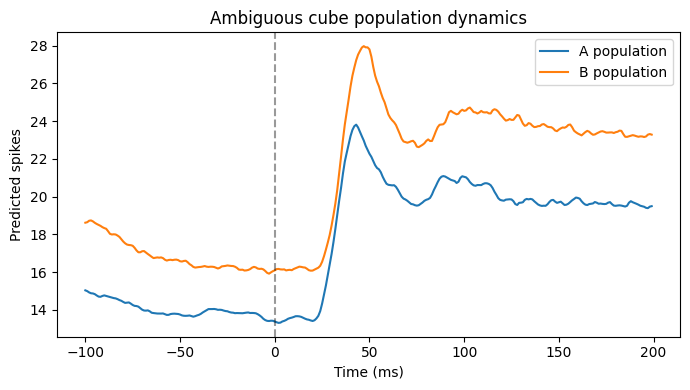

{'mean_rates': array([[19.205833 , 19.641106 , 18.747536 , ..., 11.777614 , 14.495161 ,
         16.60196  ],
        [20.312307 , 19.159363 , 18.568584 , ..., 11.944255 , 14.709125 ,
         16.732424 ],
        [20.494282 , 21.313457 , 20.58784  , ..., 11.9032345, 14.635399 ,
         16.675037 ]], dtype=float32),
 'diff': array([-1.1064739 ,  0.48174286,  0.17895126, ..., -0.16664124,
        -0.21396351, -0.13046455], dtype=float32),
 'top_A': array([388, 384, 502, 696, 708, 716, 494, 733, 393, 387, 713, 685, 495,
        507, 412, 676, 726, 715, 717, 674, 694, 486, 721, 725, 706, 509,
        707, 688, 386, 415, 391, 722, 732, 496, 504, 498, 385, 497, 489,
        714, 506, 724, 695, 511, 503, 505, 501, 677, 490, 686]),
 'top_B': array([ 22, 596, 195,   7, 616,  15, 604,  37, 319, 209, 208,  23, 155,
        597, 294, 215, 213, 111, 607, 234, 199, 778, 589, 220, 579, 223,
          9, 311, 587, 534, 218, 119, 788, 540, 196, 212, 541, 217, 615,
        582,  38,  39, 779, 198, 787

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from berg import BERG
import torchvision.transforms as T
from PIL import Image

# =========================
# 1. CONFIG
# =========================

TOP_K = 50
TIME_WINDOW = (50, 150)  # ms
SIGMA = 1              # Gaussian smoothing

# =========================
# 2. PREPROCESSING
# =========================

def make_rgb_smooth(inp, sigma=1.0):
    """
    Convert binary cube -> smoothed RGB image
    """
    cube = np.array(inp).astype(float)

    # smooth (important for ViT features)
    cube = gaussian_filter(cube, sigma=sigma)

    # normalize to 0–255
    cube = cube - cube.min()
    if cube.max() > 0:
        cube = cube / cube.max()

    gray_255 = (cube * 255).astype(np.uint8)

    # stack into RGB
    rgb = np.stack([gray_255]*3, axis=-1)
    return rgb


def build_stimulus(images_list):
    """
    Convert list of (H,W,3) images -> (N,3,H,W)
    """
    imgs = np.stack(images_list, axis=0)        # (N, H, W, 3)
    stimulus = np.transpose(imgs, (0, 3, 1, 2)) # (N, 3, H, W)
    return stimulus


# =========================
# 3. BERG ENCODING
# =========================

def run_berg(stimulus):
    berg = BERG(berg_dir="brain-encoding-response-generator")

    model = berg.get_encoding_model(
        "utah_array-tvsd-vit_b_32",
        subject="N",
        device="cpu"
    )

    spikes, meta = berg.encode(
        model,
        stimulus,
        return_metadata=True
    )

    return spikes, meta


# =========================
# 4. ANALYSIS CORE
# =========================

def compute_mean_rates(spikes, times, t_window):
    t_mask = (times >= t_window[0]) & (times <= t_window[1])
    return spikes[:, :, t_mask].mean(axis=-1)  # (N_images, 1024)


def get_topk_indices(values, k=50):
    return np.argsort(values)[-k:]


def analyze_conditions(mean_rates, idx_A=0, idx_B=1, idx_amb=2):
    """
    Core analysis:
    - top-k electrodes
    - difference vector
    - ambiguous projection
    """

    A = mean_rates[idx_A]
    B = mean_rates[idx_B]
    amb = mean_rates[idx_amb]

    # difference axis
    diff = A - B

    # top electrodes
    top_A = get_topk_indices(diff, TOP_K)
    top_B = get_topk_indices(-diff, TOP_K)

    # correlations
    corr_A = np.corrcoef(amb, A)[0,1]
    corr_B = np.corrcoef(amb, B)[0,1]

    # projection (Hopfield-like coordinate)
    axis = A - B
    projection = np.dot(amb, axis)

    results = {
        "A": A,
        "B": B,
        "amb": amb,
        "diff": diff,
        "top_A": top_A,
        "top_B": top_B,
        "corr_A": corr_A,
        "corr_B": corr_B,
        "projection": projection
    }

    return results


# =========================
# 5. ROI ANALYSIS
# =========================

def roi_analysis(mean_rates, roi_assignments, roi_labels, idx_A=0, idx_B=1, idx_amb=2):
    A = mean_rates[idx_A]
    B = mean_rates[idx_B]
    amb = mean_rates[idx_amb]

    roi_results = {}

    for i, label in enumerate(roi_labels):
        mask = roi_assignments == i

        corr_A = np.corrcoef(amb[mask], A[mask])[0,1]
        corr_B = np.corrcoef(amb[mask], B[mask])[0,1]

        roi_results[label] = {
            "corr_A": corr_A,
            "corr_B": corr_B
        }

    return roi_results


# =========================
# 6. TIME SERIES EXTRACTION
# =========================

def extract_population_timeseries(spikes, top_indices):
    """
    Get average time series for a population
    """
    return spikes[top_indices].mean(axis=0)


# =========================
# 7. VISUALIZATION
# =========================

def plot_population_dynamics(times, spikes, top_A, top_B, idx_amb=2):
    amb_spikes = spikes[idx_amb]

    A_ts = extract_population_timeseries(amb_spikes, top_A)
    B_ts = extract_population_timeseries(amb_spikes, top_B)

    plt.figure(figsize=(7,4))
    plt.plot(times, A_ts, label="A population")
    plt.plot(times, B_ts, label="B population")
    plt.axvline(0, color="k", ls="--", alpha=0.4)
    plt.xlabel("Time (ms)")
    plt.ylabel("Predicted spikes")
    plt.title("Ambiguous cube population dynamics")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# 8. MAIN PIPELINE
# =========================

def run_full_pipeline(fap_cube, fbp_cube, ambiguous):

    # --- preprocess ---
    img_A = make_rgb_smooth(fap_cube, SIGMA)
    img_B = make_rgb_smooth(fbp_cube, SIGMA)
    img_amb = make_rgb_smooth(ambiguous, SIGMA)

    stimulus = build_stimulus([img_A, img_B, img_amb])

    # --- run BERG ---
    spikes, meta = run_berg(stimulus)

    times = meta["utah_array"]["times"]
    roi_assignments = meta["roi"]["roi_assignments"]
    roi_labels = meta["roi"]["roi_labels"]

    # --- compute rates ---
    mean_rates = compute_mean_rates(spikes, times, TIME_WINDOW)

    # --- analyze ---
    results = analyze_conditions(mean_rates)
    roi_results = roi_analysis(mean_rates, roi_assignments, roi_labels)

    # --- visualize ---
    plot_population_dynamics(times, spikes, results["top_A"], results["top_B"])

    # --- package clean output ---
    clean_output = {
        "mean_rates": mean_rates,
        "diff": results["diff"],
        "top_A": results["top_A"],
        "top_B": results["top_B"],
        "corr_A": results["corr_A"],
        "corr_B": results["corr_B"],
        "projection": results["projection"],
        "roi_results": roi_results,
        "times": times,
        "spikes": spikes
    }

    return clean_output
run_full_pipeline(fap_cube, fbp_cube, ambiguous)


Model loaded on cpu for monkey N (all training data)


Encoding Utah Array responses: 100%|██████████| 1/1 [00:00<00:00,  1.91it/s, Encoded images=3, Total images=3]


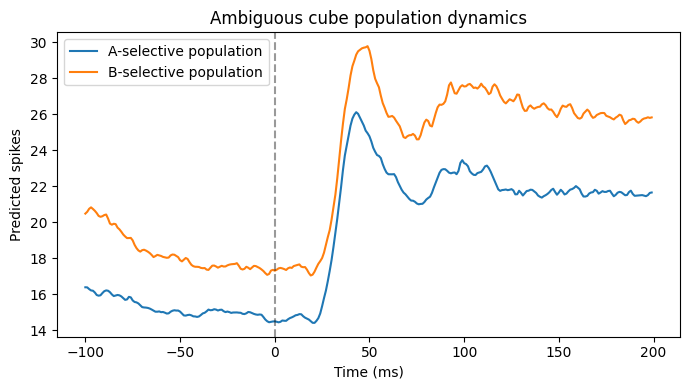


=== SELECTIVE ELECTRODES ===
Top A electrodes: [415 722 732 504 496 498 385 497 489 506 714 724 695 511 503 505 501 686
 677 490]
Top B electrodes: [588 581 580 197 219 779 787 198  39  38 615 582 541 217 212 196 540 788
 119 587]

=== UNIQUE (STRICT) ===
A_only: [707 391 490 716 686 501 503] ... total: 7
B_only: [579 580 581  38 582 587 588 212 533 540] ... total: 12

=== AMBIGUOUS RESPONSE ===
A population (amb): 22.244654
B population (amb): 26.558435
Projection: -11024.139

=== ROI SUMMARY ===
V1 {'A_mean': 19.327744, 'B_mean': 19.985302, 'AMB_mean': 20.266539}
V4 {'A_mean': 12.757051, 'B_mean': 13.222242, 'AMB_mean': 13.384371}
IT {'A_mean': 13.432982, 'B_mean': 13.807268, 'AMB_mean': 13.708959}


In [ ]:
def run_selective_electrode_pipeline(
    fap_cube,
    fbp_cube,
    ambiguous,
    top_k=20,
    sigma=0.5,
    time_window=(50, 150),
    resize_to=224
):
    import numpy as np
    from scipy.ndimage import gaussian_filter
    from PIL import Image
    from berg import BERG
    import matplotlib.pyplot as plt

    # =========================
    # 1. PREPROCESSING
    # =========================
    def make_rgb_smooth(inp):
        cube = np.array(inp).astype(float)

        # Gaussian smoothing
        cube = gaussian_filter(cube, sigma=sigma)

        # normalize
        cube = cube - cube.min()
        if cube.max() > 0:
            cube = cube / cube.max()

        # to 0–255
        gray = (cube * 255).astype(np.uint8)

        # RGB
        rgb = np.stack([gray]*3, axis=-1)

        # resize (important for ViT)
        img = Image.fromarray(rgb).resize((resize_to, resize_to))
        return np.array(img)

    img_A = make_rgb_smooth(fap_cube)
    img_B = make_rgb_smooth(fbp_cube)
    img_amb = make_rgb_smooth(ambiguous)

    # stack → (N, 3, H, W)
    imgs = np.stack([img_A, img_B, img_amb], axis=0)
    stimulus = np.transpose(imgs, (0, 3, 1, 2))

    # =========================
    # 2. RUN BERG
    # =========================
    berg = BERG(berg_dir="brain-encoding-response-generator")

    model = berg.get_encoding_model(
        "utah_array-tvsd-vit_b_32",
        subject="N",
        device="cpu"
    )

    spikes, meta = berg.encode(model, stimulus, return_metadata=True)

    times = meta["utah_array"]["times"]
    roi_assignments = meta["roi"]["roi_assignments"]
    roi_labels = meta["roi"]["roi_labels"]

    # =========================
    # 3. MEAN FIRING RATES
    # =========================
    t_mask = (times >= time_window[0]) & (times <= time_window[1])
    mean_rates = spikes[:, :, t_mask].mean(axis=-1)  # (3, 1024)

    A = mean_rates[0]
    B = mean_rates[1]
    AMB = mean_rates[2]

    # =========================
    # 4. SELECTIVITY (KEY STEP)
    # =========================
    diff = A - B

    # top-k electrodes (your "20 + 20 neurons")
    top_A = np.argsort(diff)[-top_k:]
    top_B = np.argsort(diff)[:top_k]

    # =========================
    # 5. OPTIONAL: STRICT UNIQUE SETS
    # =========================
    act_thresh = np.percentile(mean_rates, 85)

    A_active = np.where(A > act_thresh)[0]
    B_active = np.where(B > act_thresh)[0]

    A_only = np.array(list(set(A_active) - set(B_active)))
    B_only = np.array(list(set(B_active) - set(A_active)))

    # =========================
    # 6. AMBIGUOUS RESPONSE
    # =========================
    A_pop_amb = AMB[top_A].mean()
    B_pop_amb = AMB[top_B].mean()

    # projection (percept axis)
    projection = np.dot(AMB, (A - B))

    # =========================
    # 7. TIME SERIES (IMPORTANT)
    # =========================
    spikes_amb = spikes[2]

    A_ts = spikes_amb[top_A].mean(axis=0)
    B_ts = spikes_amb[top_B].mean(axis=0)

    # =========================
    # 8. ROI BREAKDOWN
    # =========================
    roi_results = {}

    for i, label in enumerate(roi_labels):
        mask = roi_assignments == i

        roi_results[label] = {
            "A_mean": A[mask].mean(),
            "B_mean": B[mask].mean(),
            "AMB_mean": AMB[mask].mean()
        }

    # =========================
    # 9. VISUALIZATION
    # =========================
    plt.figure(figsize=(7,4))
    plt.plot(times, A_ts, label="A-selective population")
    plt.plot(times, B_ts, label="B-selective population")
    plt.axvline(0, color="k", ls="--", alpha=0.4)
    plt.xlabel("Time (ms)")
    plt.ylabel("Predicted spikes")
    plt.title("Ambiguous cube population dynamics")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =========================
    # 10. PRINT SUMMARY
    # =========================
    print("\n=== SELECTIVE ELECTRODES ===")
    print("Top A electrodes:", top_A)
    print("Top B electrodes:", top_B)

    print("\n=== UNIQUE (STRICT) ===")
    print("A_only:", A_only[:10], "... total:", len(A_only))
    print("B_only:", B_only[:10], "... total:", len(B_only))

    print("\n=== AMBIGUOUS RESPONSE ===")
    print("A population (amb):", A_pop_amb)
    print("B population (amb):", B_pop_amb)
    print("Projection:", projection)

    print("\n=== ROI SUMMARY ===")
    for k, v in roi_results.items():
        print(k, v)

    # =========================
    # 11. RETURN CLEAN OUTPUT
    # =========================
    return {
        "top_A": top_A,
        "top_B": top_B,
        "A_only": A_only,
        "B_only": B_only,
        "A_pop_amb": A_pop_amb,
        "B_pop_amb": B_pop_amb,
        "projection": projection,
        "A_ts": A_ts,
        "B_ts": B_ts,
        "times": times,
        "spikes": spikes,
        "mean_rates": mean_rates,
        "roi_results": roi_results
    }
result = run_selective_electrode_pipeline(
    fap_cube,
    fbp_cube,
    ambiguous
)


Model loaded on cpu for monkey N (all training data)
(1, 1024, 300)


Encoding Utah Array responses: 100%|██████████| 1/1 [00:00<00:00,  3.37it/s, Encoded images=1, Total images=1]


<class 'dict'>
dict_keys(['utah_array', 'roi', 'encoding_model'])
utah_array <class 'dict'>
roi <class 'dict'>
encoding_model <class 'dict'>
dict_keys(['times', 'monkey_id', 'n_electrodes', 'electrode_order'])
dict_keys(['roi_assignments', 'roi_labels'])
dict_keys(['all_training_splits', 'test_img_ids', 'test_stimuli', 'test_concepts', 'test_days', 'test_sequence_pos', 'SNR', 'SNR_max', 'ncsnr', 'noise_ceiling', 'single_training_split_1', 'single_training_split_2', 'single_training_split_3', 'single_training_split_4'])


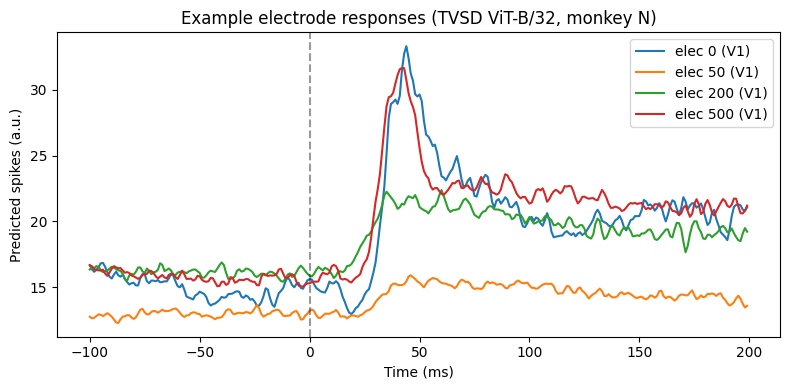

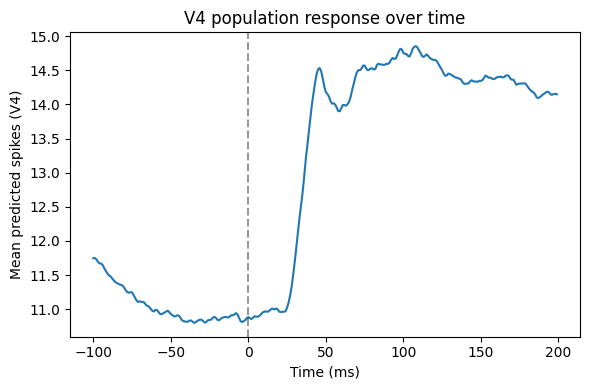

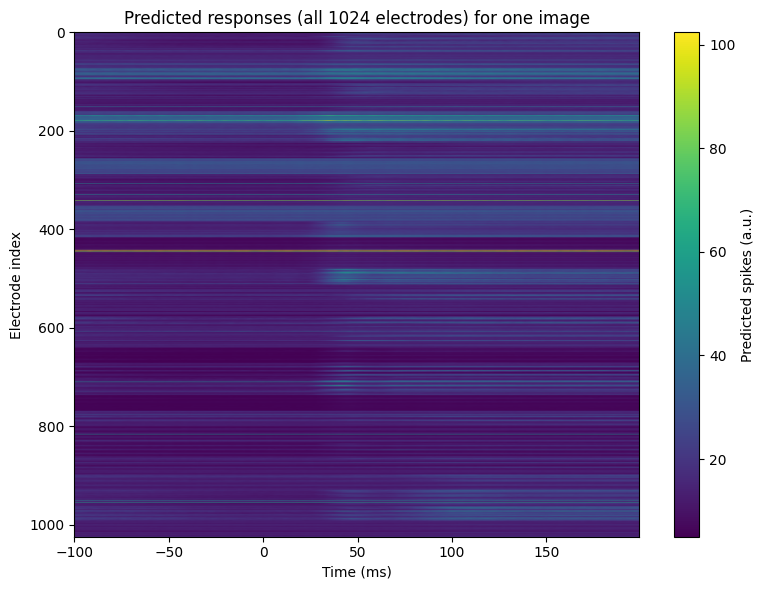

In [ ]:
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
from berg import BERG
import requests
from io import BytesIO


berg = BERG(berg_dir="brain-encoding-response-generator")
tvsd_model = berg.get_encoding_model("utah_array-tvsd-vit_b_32",
                                     subject="N", device="cpu")

# torchvision transform matching ViT-B/32 preproc (approximate)
transform = T.Compose([
    T.Resize(224),
    T.CenterCrop(224),
    T.ToTensor(),  # -> (C, H, W) float32 in [0,1]
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # check docs if you want exact
])
url = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
img_np = np.array(img)  # shape (H, W, 3), dtype uint8
x = transform(img)        # (3, H, W)
x = x.unsqueeze(0)        # (1, 3, H, W)
stimulus = x.numpy()      # 4D numpy array

spikes = tvsd_model.generate_response(stimulus, show_progress=False)
print(spikes.shape)       # (1, 1024, 300)
# After you have berg and tvsd_model:
_, meta = berg.encode(tvsd_model, stimulus, return_metadata=True)
insilico_spikes, meta = berg.encode(tvsd_model, stimulus, return_metadata=True)

print(type(meta))
print(meta.keys())
for k, v in meta.items():
    print(k, type(v))
print(meta["utah_array"].keys())
print(meta["roi"].keys())
print(meta["encoding_model"].keys())

spikes_arr = spikes[0]  # (1024, 300) for this single image

times = meta["utah_array"]["times"]              # (300,)
roi_assignments = meta["roi"]["roi_assignments"] # (1024,)
roi_labels = meta["roi"]["roi_labels"]           # ['V1', 'V4', 'IT']
import matplotlib.pyplot as plt

example_electrodes = [0, 50, 200, 500]  # pick any indices

plt.figure(figsize=(8, 4))
for eid in example_electrodes:
    area_idx = roi_assignments[eid]        # 0,1,2
    area_name = roi_labels[area_idx]       # 'V1','V4','IT'
    plt.plot(times, spikes_arr[eid], label=f"elec {eid} ({area_name})")

plt.axvline(0, color="k", linestyle="--", alpha=0.4)
plt.xlabel("Time (ms)")
plt.ylabel("Predicted spikes (a.u.)")
plt.legend()
plt.title("Example electrode responses (TVSD ViT-B/32, monkey N)")
plt.tight_layout()
plt.show()
v4_mask = roi_assignments == 1   # 0=V1, 1=V4, 2=IT
v4_spikes = spikes_arr[v4_mask]  # (n_v4, 300)
v4_mean = v4_spikes.mean(axis=0)

plt.figure(figsize=(6, 4))
plt.plot(times, v4_mean)
plt.axvline(0, color="k", linestyle="--", alpha=0.4)
plt.xlabel("Time (ms)")
plt.ylabel("Mean predicted spikes (V4)")
plt.title("V4 population response over time")
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
plt.imshow(spikes_arr, aspect="auto", cmap="viridis",
           extent=[times[0], times[-1], spikes_arr.shape[0], 0])
plt.colorbar(label="Predicted spikes (a.u.)")
plt.xlabel("Time (ms)")
plt.ylabel("Electrode index")
plt.title("Predicted responses (all 1024 electrodes) for one image")
plt.tight_layout()
plt.show()



(3, 3, 775, 775)


Encoding Utah Array responses: 100%|██████████| 1/1 [00:00<00:00,  1.48it/s, Encoded images=3, Total images=3]


(3, 1024, 300)


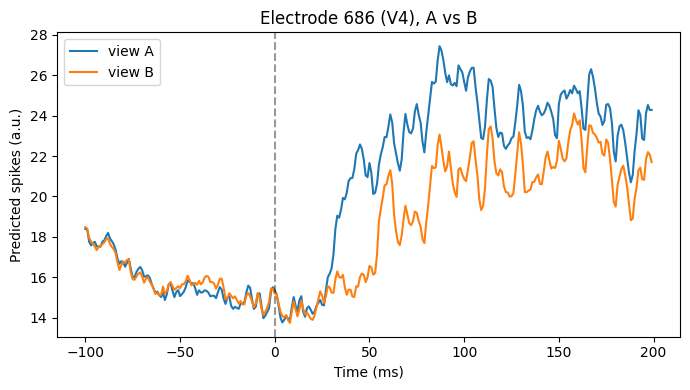

In [ ]:
import numpy as np
from PIL import Image
from io import BytesIO
import requests

# list of URLs or local paths for your Necker variants
# urls = [
#     "https://.../necker_plain.png",
#     "https://.../necker_biased_view1.png",
#     "https://.../necker_biased_view2.png",
#     # ...
# ]

images_np = []
# for url in urls:
#     img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
#     images_np.append(np.array(img))   # (H,W,3)
import numpy as np

def makergb(inp):
    cube = np.array(inp)  # (H, W) 0/1 or 0..1

    # scale to 0–255
    gray_255 = (cube * 255).clip(0, 255).astype(np.uint8)  # (H, W)

    # make 3-channel RGB
    rgb = np.stack([gray_255] * 3, axis=-1)               # (H, W, 3), uint8
    return rgb

images_np = []
import numpy as np
from berg import BERG

def makergb(inp):
    cube = np.array(inp)        # (H, W), 0/1
    gray_255 = (cube * 255).clip(0, 255).astype(np.uint8)
    rgb = np.stack([gray_255] * 3, axis=-1)  # (H, W, 3)
    return rgb

# Build list of images: each element is (H, W, 3), uint8
# Build list of images: (H, W, 3)
images_list = [
    makergb(fap_cube),
    makergb(fbp_cube),
    makergb(ambiguous),
]

# Stack and reorder to (N, 3, H, W) because utah_array model expects that
imgs = np.stack(images_list, axis=0)        # (N, H, W, 3)
stimulus = np.transpose(imgs, (0, 3, 1, 2)) # (N, 3, H, W)

print(stimulus.shape)  # should be (3, 3, H, W)

insilico_spikes, meta = berg.encode(
    tvsd_model,
    stimulus,              # 4D numpy array
    return_metadata=True
)

print(insilico_spikes.shape)  # (3, 1024, 300)
# insilico_spikes: (3, 1024, 300)

# insilico_spikes: (N_images, 1024, 300)
import matplotlib.pyplot as plt
#---

times = meta["utah_array"]["times"]              # (300,)
roi_assignments = meta["roi"]["roi_assignments"] # (1024,)
roi_labels = meta["roi"]["roi_labels"]           # ['V1','V4','IT']

# choose a time window
t_mask = (times >= 50) & (times <= 150)

# mean rate in that window: (N_images, 1024)
mean_rates = insilico_spikes[:, :, t_mask].mean(axis=-1)
idx_view1 = [0, 1, 2]   # first three images bias orientation A
# mean_rates: (3, 1024)
idx_view1 = [0]  # fap_cube
idx_view2 = [1]  # fbp_cube

view1_mean = mean_rates[idx_view1].mean(axis=0)  # (1024,)
view2_mean = mean_rates[idx_view2].mean(axis=0)  # (1024,)
diff = view1_mean - view2_mean                   # (1024,)

top_A = np.argsort(diff)[-20:]
top_B = np.argsort(diff)[:20]

v4_mask = roi_assignments == 1
v4_indices = np.where(v4_mask)[0]

v4_diff = diff[v4_mask]
top_v4_A = v4_indices[np.argsort(v4_diff)[-20:]]
top_v4_B = v4_indices[np.argsort(v4_diff)[:20]]

# choose one image from each condition
iA = idx_view1[0]
iB = idx_view2[0]

spikes_A = insilico_spikes[iA]  # (1024,300)
spikes_B = insilico_spikes[iB]

eid = int(top_v4_A[-1])

plt.figure(figsize=(7,4))
plt.plot(times, spikes_A[eid], label="view A")
plt.plot(times, spikes_B[eid], label="view B")
plt.axvline(0, color="k", ls="--", alpha=0.4)
plt.xlabel("Time (ms)")
plt.ylabel("Predicted spikes (a.u.)")
plt.title(f"Electrode {eid} ({roi_labels[roi_assignments[eid]]}), A vs B")
plt.legend()
plt.tight_layout()
plt.show()






In [ ]:
def check_patterns():
    fa_state = pattern_FA.copy()
    fb_state = pattern_FB.copy()

    print("FA classified as:", classify(fa_state))
    print("FB classified as:", classify(fb_state))

    print("Overlap FA with FA:", np.mean(fa_state * pattern_FA))
    print("Overlap FA with FB:", np.mean(fa_state * pattern_FB))

    print("Overlap FB with FB:", np.mean(fb_state * pattern_FB))
    print("Overlap FB with FA:", np.mean(fb_state * pattern_FA))
mask = (fap_cube != fbp_cube)  # only differing pixels

pattern_FA = np.where(fap_cube[mask] > 0, 1, -1)
pattern_FB = np.where(fbp_cube[mask] > 0, 1, -1)
print("FA:", pattern_FA)
print("FB:", pattern_FB)

necker_pattern = np.where(ambiguous[mask] > 0, 1, -1)
check_patterns()
print("Ambiguous overlaps:")
print("FA:", np.mean(necker_pattern * pattern_FA))
print("FB:", np.mean(necker_pattern * pattern_FB))

FA: [-1 -1  1 -1  1 -1  1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1  1 -1  1 -1
  1 -1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1 -1  1  1]
FB: [ 1  1 -1  1 -1  1 -1  1  1  1  1  1  1 -1  1  1  1  1 -1  1 -1  1 -1  1
 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1  1 -1 -1]
FA classified as: 1
FB classified as: -1
Overlap FA with FA: 1.0
Overlap FA with FB: -1.0
Overlap FB with FB: 1.0
Overlap FB with FA: -1.0
Ambiguous overlaps:
FA: 0.045454545454545456
FB: -0.045454545454545456


Streaming output truncated to the last 5000 lines.
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


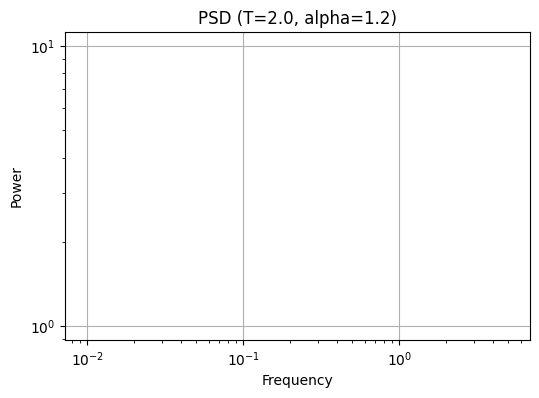

In [ ]:
import numpy as np
necker_bin = np.array(ambiguous, dtype=int)
# Convert 0-> -1, 1-> +1 for Hopfield states
necker_pattern = np.where(necker_bin.flatten()==1, 1, -1)
N=necker_pattern.size
#the two perceptual interpretations
pattern_FA = np.where(fap_cube.flatten() > 0, 1, -1)
pattern_FB = np.where(fbp_cube.flatten() > 0, 1, -1)
# Basic Hopfield weights from two patterns:
W = (np.outer(pattern_FA, pattern_FA) + np.outer(pattern_FB, pattern_FB)) / N
np.fill_diagonal(W, 0)  # no self-connections
# Introduce bias: scale FA pattern by factor alpha
alpha = 1.0  # bias strength (1.0 = neutral)
W_biased = alpha * np.outer(pattern_FA, pattern_FA) + np.outer(pattern_FB, pattern_FB)
np.fill_diagonal(W_biased, 0)

import random

def hopfield_step(state, W, T):
    i = np.random.randint(N)
    # compute energy change if neuron i flips
    h_i = W[i,:] @ state  # local field
    dE = 2 * state[i] * h_i  # energy difference for flip
    if dE < 0 or random.random() < np.exp(-dE / T):
        state[i] *= -1
    return state

# Example simulation:
T = 1.0  # noise temperature
state = necker_pattern.copy()  # start from input
for sweep in range(10000):
    state = hopfield_step(state, W_biased, T)
def classify(state):
    # Compute overlaps
    overlap_FA = (state * pattern_FA).mean()
    overlap_FB = (state * pattern_FB).mean()
    return 1 if overlap_FA > overlap_FB else -1

# Collect a time series of percepts
percepts = []
state = necker_pattern.copy()
for sweep in range(100000):
    state = hopfield_step(state, W_biased, T)
    if sweep % 10 == 0:  # sample every few updates
        percepts.append(classify(state))
        print(percepts[-1])
percepts = np.array(percepts)
bias_vals = [0.8, 1.0, 1.2]  # example bias scaling for FA
temperatures = np.linspace(0.1, 2.0, 10)
results = {}
for alpha in bias_vals:
    W_biased = alpha * np.outer(pattern_FA, pattern_FA) + np.outer(pattern_FB, pattern_FB)
    np.fill_diagonal(W_biased, 0)
    for T in temperatures:
        # run simulation (long) to measure switching
        state = necker_pattern.copy()
        percepts = []
        for sweep in range(500000):
            state = hopfield_step(state, W_biased, T)
            percepts.append(classify(state))
        # Compute switching rate or PSD peak, etc.
        switches = np.sum(np.abs(np.diff(percepts))) / 2
        results[(alpha,T)] = switches
from scipy.signal import welch
percepts = np.array(percepts)
freqs, power = welch(percepts, fs=10.0, nperseg=min(1024, len(percepts)))
# Identify peak near any driving freq or compute total power.
plt.figure(figsize=(6,4))
plt.loglog(freqs[1:], power[1:])   # skip zero freq
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.title(f"PSD (T={T}, alpha={alpha})")
plt.grid(True)
plt.show()
